In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path 
# Імпортуйте ваші класи (якщо вони в іншому файлі, змініть імпорт)
# з вашого_файлу import SpeakerLightningModule, AMISpeakerDataModule
from third_model import SpeakerLightningModule, AMISpeakerDataModule


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
C:\Users\gaszt\miniconda3\envs\NLP\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Усього унікальних мовців знайдено: 173


In [4]:

def run_similarity_test(checkpoint_path, audio_dir, val_rttm_dir, batch_size=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # 1. Ініціалізація DataModule для отримання словника мовців та завантажувача даних
    print("Preparing data...")
    # Трейнінг RTTM передаємо як None, бо для тесту нам потрібен лише валідаційний/тестовий сет
    data_module = AMISpeakerDataModule(
        audio_dir=audio_dir,
        train_rttm_dir=Path('./'), 
        val_rttm_dir=val_rttm_dir,
        batch_size=batch_size,
        num_workers=0
    )
    # Ініціалізуємо датасет вручну через setup
    data_module.setup(stage="validate")
    val_loader = data_module.val_dataloader()

    # 2. Завантаження навченої моделі з чекпоінту
    print(f"Loading checkpoint from: {checkpoint_path}")
    model = SpeakerLightningModule.load_from_checkpoint(checkpoint_path)
    model.to(device)
    model.eval()  # Переводимо в режим оцінювання (вимкнення dropout, batchnorm у режим тесту)

    all_embeddings = []
    all_labels = []

    # 3. Екстракція ембедінгів для всієї вибірки
    print("Extracting speaker embeddings...")
    with torch.no_grad():
        for batch in tqdm(val_loader):
            waveforms, labels = batch
            waveforms = waveforms.to(device)

            # Отримуємо L2-нормалізовані ембедінги
            embeddings = model(waveforms)

            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels)

            
    # Об'єднуємо всі батчі в єдині тензори
    all_embeddings = torch.cat(all_embeddings, dim=0)  # [N, 256]
    all_labels = torch.cat(all_labels, dim=0)          # [N]
    
    num_samples = all_embeddings.size(0)
    print(f"Extracted {num_samples} audio segments.")

    # 4. Обчислення косинусної подібності
    # Оскільки ембедінги вже L2-нормалізовані в моделі, матричне множення дає саме Cosine Similarity
    print("Computing pairwise cosine similarity matrix...")
    similarity_matrix = torch.mm(all_embeddings, all_embeddings.t()) # [N, N]

    # 5. Створення масок для фільтрації результатів
    # Матриця, де True означає, що мовці однакові
    same_speaker_mask = (all_labels.unsqueeze(0) == all_labels.unsqueeze(1))
    
    # Виключаємо діагональ (порівняння аудіо-сегмента з самим собою, де схожість завжди 1.0)
    diag_mask = torch.eye(num_samples, dtype=torch.bool)
    same_speaker_mask = same_speaker_mask & ~diag_mask
    diff_speaker_mask = ~same_speaker_mask & ~diag_mask

    # Витягуємо значення у вигляді одновимірних векторів (numpy для зручності аналізу)
    same_speaker_sims = similarity_matrix[same_speaker_mask].numpy()
    diff_speaker_sims = similarity_matrix[diff_speaker_mask].numpy()

    # 6. Розрахунок та вивід статистичних метрик
    print("\n" + "="*40)
    print("  COSINE SIMILARITY TEST RESULTS  ")
    print("="*40)
    
    if len(same_speaker_sims) > 0:
        print(f"Same Speaker (Positive Pairs) - Total: {len(same_speaker_sims)}")
        print(f"  Mean Similarity:   {np.mean(same_speaker_sims):.4f}")
        print(f"  Median Similarity: {np.median(same_speaker_sims):.4f}")
        print(f"  Std Deviation:     {np.std(same_speaker_sims):.4f}")
        print(f"  Min Similarity:    {np.min(same_speaker_sims):.4f}")
        print(f"  Max Similarity:    {np.max(same_speaker_sims):.4f}")
    else:
        print("No same speaker pairs found in the batch/dataset!")

    print("-" * 40)
    
    if len(diff_speaker_sims) > 0:
        print(f"Different Speakers (Negative Pairs) - Total: {len(diff_speaker_sims)}")
        print(f"  Mean Similarity:   {np.mean(diff_speaker_sims):.4f}")
        print(f"  Median Similarity: {np.median(diff_speaker_sims):.4f}")
        print(f"  Std Deviation:     {np.std(diff_speaker_sims):.4f}")
        print(f"  Min Similarity:    {np.min(diff_speaker_sims):.4f}")
        print(f"  Max Similarity:    {np.max(diff_speaker_sims):.4f}")
    else:
        print("No different speaker pairs found!")
    print("="*40)

    # 7. Візуалізація розподілу (Побудова НОРМОВАНОЇ гістограми)
    plt.figure(figsize=(10, 6))
    
    # Додаємо density=True для відображення щільності ймовірності замість кількості
    if len(same_speaker_sims) > 0:
        plt.hist(same_speaker_sims, bins=50, alpha=0.6, density=True, 
                 label='Same Speaker (Positives)', color='g', edgecolor='black')
                 
    if len(diff_speaker_sims) > 0:
        plt.hist(diff_speaker_sims, bins=50, alpha=0.6, density=True, 
                 label='Different Speakers (Negatives)', color='r', edgecolor='black')
        
    plt.title('Normalized Distribution of Cosine Similarities')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Density (Probability)') # Змінено назву осі Y
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Зберігаємо графік у файл
    output_plot = "speaker_similarity_distribution_normalized.png"
    plt.savefig(output_plot)
    print(f"Normalized distribution plot saved as '{output_plot}'")
    plt.show()
    
    # # 7. Візуалізація розподілу (Побудова гістограми)
    # plt.figure(figsize=(10, 6))
    # if len(same_speaker_sims) > 0:
    #     plt.hist(same_speaker_sims, bins=50, alpha=0.6, label='Same Speaker (Positives)', color='g', edgecolor='black')
    # if len(diff_speaker_sims) > 0:
    #     plt.hist(diff_speaker_sims, bins=50, alpha=0.6, label='Different Speakers (Negatives)', color='r', edgecolor='black')
    #     
    # plt.title('Distribution of Cosine Similarities')
    # plt.xlabel('Cosine Similarity')
    # plt.ylabel('Frequency')
    # plt.legend(loc='upper left')
    # plt.grid(True, linestyle='--', alpha=0.5)
    # 
    # # Зберігаємо графік у файл
    # output_plot = "speaker_similarity_distribution.png"
    # plt.savefig(output_plot)
    # print(f"Distribution plot saved as '{output_plot}'")
    # plt.show()


Using device: cuda
Preparing data...
Усього унікальних мовців знайдено: 16
Loading checkpoint from: ./lightning_logs/version_37/checkpoints/epoch=9-step=42660.ckpt
Extracting speaker embeddings...


100%|██████████| 483/483 [00:09<00:00, 51.81it/s]


Extracted 15449 audio segments.
Computing pairwise cosine similarity matrix...

  COSINE SIMILARITY TEST RESULTS  
Same Speaker (Positive Pairs) - Total: 17977620
  Mean Similarity:   0.3938
  Median Similarity: 0.4031
  Std Deviation:     0.2219
  Min Similarity:    -0.4867
  Max Similarity:    0.9780
----------------------------------------
Different Speakers (Negative Pairs) - Total: 220678532
  Mean Similarity:   0.0331
  Median Similarity: 0.0176
  Std Deviation:     0.1668
  Min Similarity:    -0.6362
  Max Similarity:    1.0000
Normalized distribution plot saved as 'speaker_similarity_distribution_normalized.png'


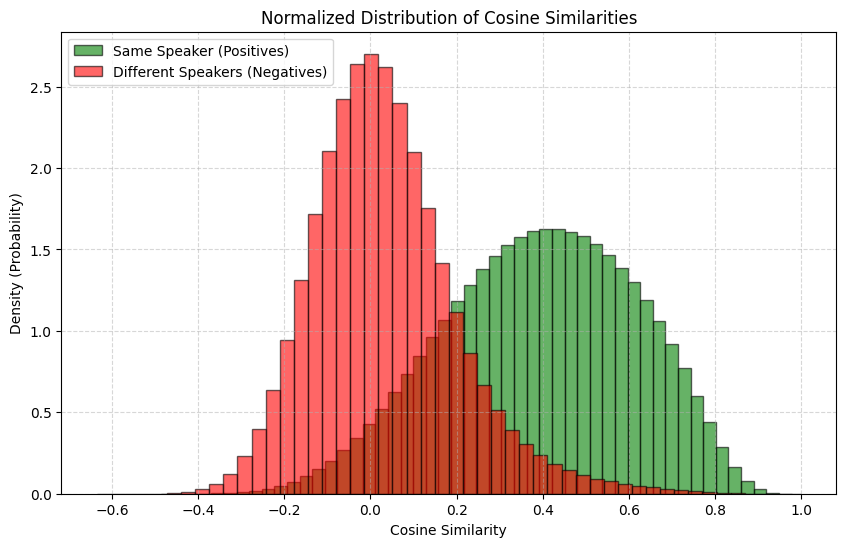

In [5]:

if __name__ == '__main__':
    # Вкажіть ваші шляхи до даних та збереженого чекпоінту після тренування
    CHECKPOINT_PATH = "./lightning_logs/model_three/checkpoints/epoch=9-step=42660.ckpt" # замініть на ваш реальний шлях
    AUDIO_DIR = './pyannote/amicorpus'
    VAL_RTTM_DIR = './only_words/rttms/test'

    run_similarity_test(
        checkpoint_path=CHECKPOINT_PATH,
        audio_dir=AUDIO_DIR,
        val_rttm_dir=VAL_RTTM_DIR,
        batch_size=32
    )